In [1]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/My Drive/[2024-2025] AN2DL

Mounted at /gdrive
/gdrive/My Drive/[2024-2025] AN2DL


In [15]:
import pickle

with open("encoded_crawled_user2user_non_blocking_X.pkl", 'rb') as f:
    non_blocking_X = pickle.load(f)

with open("encoded_crawled_user2user_non_blocking_Y.pkl", 'rb') as f:
    non_blocking_Y = pickle.load(f)

with open("encoded_crawled_user2user_blocking_X.pkl", 'rb') as f:
    blocking_X_dirty = pickle.load(f)

with open("encoded_crawled_user2user_blocking_Y.pkl", 'rb') as f:
    blocking_Y = pickle.load(f)


blocking_X=[]

for el in blocking_X_dirty:
  if len(el)!=0:
    blocking_X.append(el)

blocking_Y= blocking_Y[:len(blocking_X)]

print(len(blocking_X))
print(len(blocking_Y))



dataset_X=non_blocking_X + blocking_X

dataset_Y=non_blocking_Y + blocking_Y

print(len(dataset_X))

print(len(dataset_Y))

import random

combined = list(zip(dataset_X, dataset_Y))
random.shuffle(combined)

dataset_x_shuf, dataset_y_shuf = zip(*combined)

# if you want lists again
dataset_X_dirty = list(dataset_x_shuf)
dataset_Y = list(dataset_y_shuf)

339
339
799
799


0.1414267834793492


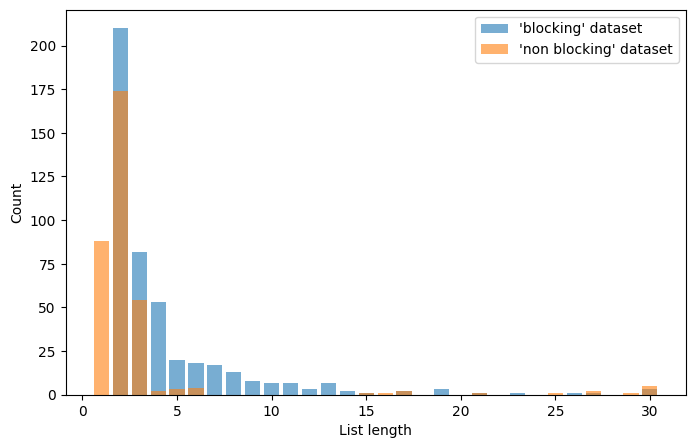

In [23]:
import matplotlib.pyplot as plt
from collections import Counter


co=0
for el in non_blocking_X+ blocking_X:
    if len(el)>5:
        co+=1

print(co/len(non_blocking_X+ blocking_X))


lengths1 = [len(seq) for seq in non_blocking_X]
counts1 = Counter(lengths1)

x1= sorted(counts1.keys())
y1 = [counts1[length] for length in x1]

lengths2 = [len(seq) for seq in blocking_X]
counts2 = Counter(lengths2)

x2= sorted(counts2.keys())
y2 = [counts2[length] for length in x2]

plt.figure(figsize=(8, 5))
plt.bar(x1, y1, alpha=0.6, label="'blocking' dataset")
plt.bar(x2, y2, alpha=0.6, label="'non blocking' dataset")
plt.xlabel("List length")
plt.ylabel("Count")
plt.legend()
plt.show()

In [18]:
from joblib import load
from sklearn.metrics import accuracy_score
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

dataset_X = pad_sequences(
    dataset_X,
    maxlen=30,
    padding="post",
    truncating="post",
    value=0,
    dtype="float32"
)

dataset_X_flat=[]

for el in dataset_X:
  dataset_X_flat.append(el.flatten())

dataset_X_flat=np.array(dataset_X_flat)
print(dataset_X_flat.shape)

rf_model = load("rf_complete.joblib")

y_pred = rf_model.predict(dataset_X_flat)

print("Accuracy:", accuracy_score(dataset_Y, y_pred))
print(classification_report(dataset_Y, y_pred))


(799, 3060)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Accuracy: 0.5757196495619524
              precision    recall  f1-score   support

           0       0.58      1.00      0.73       460
           1       0.50      0.00      0.01       339

    accuracy                           0.58       799
   macro avg       0.54      0.50      0.37       799
weighted avg       0.54      0.58      0.42       799



In [28]:
with open("sli_final_dataset_X.pkl", 'rb') as f:
    X = pickle.load(f)

with open("sli_final_dataset_Y.pkl", 'rb') as f:
    Y = pickle.load(f)

X_filtered=[]
Y_filtered=[]

for i in range(len(X)):
  if len(X[i])>4:
    X_filtered.append(X[i])
    Y_filtered.append(Y[i])

dataset_X_filtered = pad_sequences(
    X_filtered,
    maxlen=30,
    padding="post",
    truncating="post",
    value=0,
    dtype="float32"
)

dataset_X_flat=[]

for el in dataset_X_filtered:
  dataset_X_flat.append(el.flatten())

dataset_X_flat=np.array(dataset_X_flat)
print(dataset_X_flat.shape)

rf_model = load("rf_complete.joblib")

y_pred = rf_model.predict(dataset_X_flat)

print("Accuracy:", accuracy_score(Y_filtered, y_pred))
print(classification_report(Y_filtered, y_pred))



(2404, 3060)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Accuracy: 0.9891846921797005
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1202
           1       0.99      0.99      0.99      1202

    accuracy                           0.99      2404
   macro avg       0.99      0.99      0.99      2404
weighted avg       0.99      0.99      0.99      2404



In [19]:
dataset_X= []

for seq in dataset_X_dirty:
    new_seq = []
    for event in seq:
        if len(event) > 22:
            new_event = event[:22] + event[23:]
        else:
            new_event = event.copy()
        new_seq.append(new_event)

    dataset_X.append(new_seq)

In [20]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences

EPS = 1e-6

dataset_X = pad_sequences(
    dataset_X,
    maxlen=30,
    padding="post",
    truncating="post",
    value=0,
    dtype="float32"
)

# mask_padding = np.all(dataset_X == 0.0, axis=-1)  # True where padding rows are
# dataset_X = np.where(
#     (dataset_X == 0.0) & (~mask_padding[..., None]),
#     EPS,
#     dataset_X
# )

dataset_Y = np.array(dataset_Y, dtype=np.float32)

# 1. Load trained model
model = load_model("final_lstm.keras")

# 2. Evaluate model on test data
loss, accuracy = model.evaluate(dataset_X, dataset_Y, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 3. Run predictions
predictions = model.predict(dataset_X)

# If this is a classification model:
y_pred = (predictions.flatten() >= 0.5).astype(int)
y_true = dataset_Y.astype(int)

# 4. Show evaluation results
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# 5. Show a few sample predictions
print("\nSample predictions:")
for i in range(5):
    print(f"Sample {i}")
    print(f"  True label: {y_true[i]}")
    print(f"  Predicted:  {y_pred[i]}")
    print(f"  Probabilities: {predictions[i]}")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Loss: 0.2683
Test Accuracy: 0.9136
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       460
           1       0.95      0.84      0.89       339

    accuracy                           0.91       799
   macro avg       0.92      0.90      0.91       799
weighted avg       0.92      0.91      0.91       799


Confusion Matrix:
[[444  16]
 [ 53 286]]

Sample predictions:
Sample 0
  True label: 0
  Predicted:  0
  Probabilities: [0.00360849]
Sample 1
  True label: 0
  Predicted:  0
  Probabilities: [0.03785973]
Sample 2
  True label: 0
  Predicted:  0
  Probabilities: [0.0391373]
Sample 3
  True label: 0
  Predicted:  0
  Probabilities: [0.00409992]
Sample 4
  True label: 0
  Predicted:  0
  Probabilities: [0.07006341]


In [7]:
!pip install scikit-learn==1.7.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [21]:


dataset_X_flat=[]

for el in dataset_X:
  dataset_X_flat.append(el.flatten())

dataset_X_flat=np.array(dataset_X_flat)
print(dataset_X_flat.shape)

rf_model = load("rf_wo_date.joblib")

y_pred = rf_model.predict(dataset_X_flat)

print("Accuracy:", accuracy_score(dataset_Y, y_pred))
print(classification_report(dataset_Y, y_pred))

(799, 3030)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Accuracy: 0.7672090112640801
              precision    recall  f1-score   support

         0.0       0.72      0.97      0.83       460
         1.0       0.91      0.50      0.65       339

    accuracy                           0.77       799
   macro avg       0.82      0.73      0.74       799
weighted avg       0.80      0.77      0.75       799



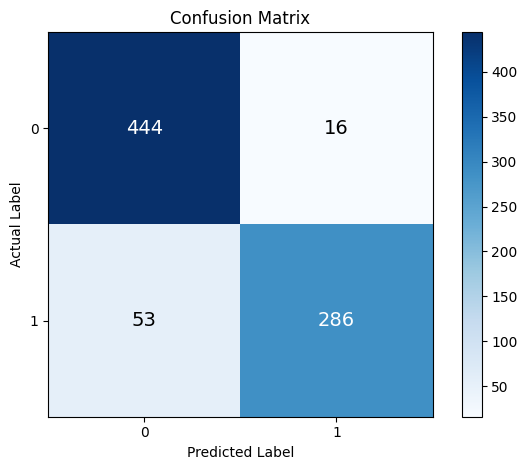

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Confusion matrix
cm = np.array([[444, 16],
               [53, 286]])

labels = ["0", "1"]

fig, ax = plt.subplots()

# Single-color colormap (darker = higher)
im = ax.imshow(cm, cmap="Blues")

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix")

# Add colorbar
plt.colorbar(im, ax=ax)

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=14
        )

plt.tight_layout()
plt.show()
